<a href="https://colab.research.google.com/github/Shuhan78/news_index_and_predict/blob/main/stock_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 4.5 MB/s eta 0:00:00
  Created wheel for snownlp: filename=snownlp-0.12.3-py3-none-any.whl size=37760946 sha256=9582e08daf865971dadc3bfe4083d051997a2a5430178176f6443e1e73fddd77
  Stored in directory: /root/.cache/pip/wheels/8a/0a/37/f15b8568f5463f1427466f701e9d3ba514035eb703f885efee
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=7a592cd844d370dc4f922af7713469ecd95357b133c86ddcbe450acaac577206
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built snownlp sgmllib3k
--- 1. 開始抓取股價: 2408 ---


/tmp/ipykernel_201/2107762539.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_price = yf.download(ticker_id, period="1mo")
[*********************100%***********************]  1 of 1 completed


--- 2. 嘗試透過 Google RSS 獲取新聞 ---
✅ 成功取得 100 則新聞


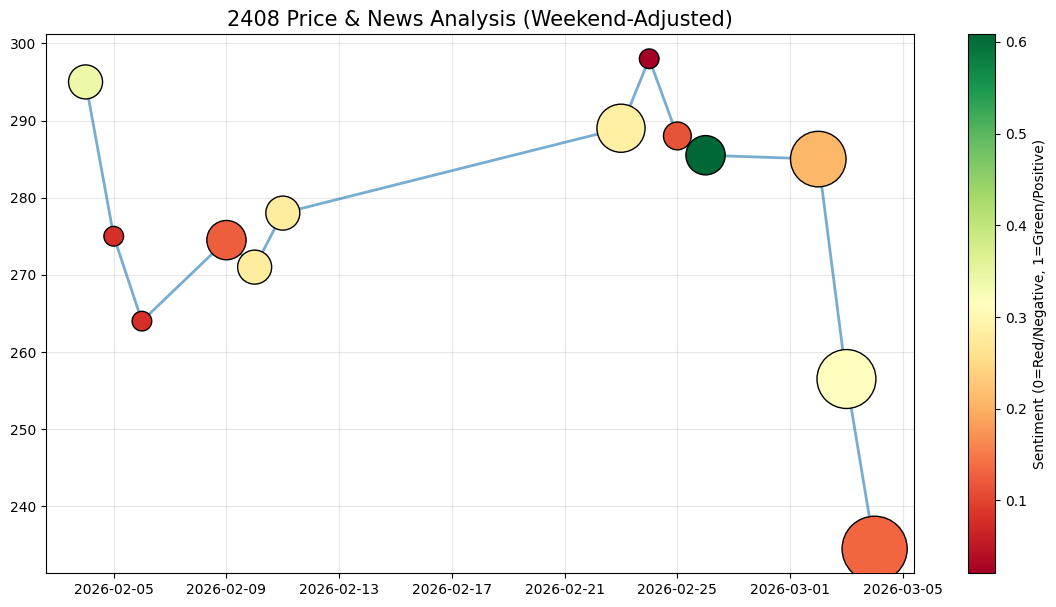


--- 數據摘要 ---
         date                                              title  sentiment
0  2026-03-04      「史上第三大跌點」台股二哥也難逃...台達電市值4天蒸發近5000億元 - Yahoo股市   0.248487
1  2026-03-03                立端今年以成長為目標，攜手台達電切入AI領域 - MoneyDJ理財網   0.001098
2  2026-03-04    【即時新聞】台達電(2308)抗跌布局首選，大盤重挫千點分析師喊買！ - CMoney投資網誌   0.172985
3  2026-02-26  台達電法說會／鄭平親跑墨西哥：產能滿載在想要去哪擴產！基本面一片大好，股價又發動8天漲快3成...   0.332011
4  2026-03-04  早盤快訊》台股下殺835點！台達電、鴻海、聯發科跌逾4%，航運跟「這族群」逆風大漲近漲停| ...   0.000723


In [ ]:
!pip install yfinance snownlp feedparser

import yfinance as yf
import pandas as pd
from snownlp import SnowNLP
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import feedparser
import time

# --- 1. 設定參數 ---
stock_id = "2308" # 新聞是搜尋「台達電」，所以代號設為台達電的 2308
ticker_id = f"{2408}.TW" # 修正這裡，讓它變成 "2308.TW"

print(f"--- 1. 開始抓取股價: {2408} ---")
df_price = yf.download(ticker_id, period="1mo")

# 確保抓到股價
if df_price.empty:
    ticker_id = f"{2408}.TWO"
    df_price = yf.download(ticker_id, period="1mo")

# 處理 yfinance 新版的格式問題
if isinstance(df_price.columns, pd.MultiIndex):
    df_price = df_price['Close']
else:
    df_price = df_price[['Close']]

df_price.index = pd.to_datetime(df_price.index).tz_localize(None)

# --- 2. 抓取新聞 (Google RSS) ---
news_list = []
print(f"--- 2. 嘗試透過 Google RSS 獲取新聞 ---")
rss_url = f"https://news.google.com/rss/search?q=+台達電&hl=zh-TW&gl=TW&ceid=TW:zh-Hant"
feed = feedparser.parse(rss_url)

for entry in feed.entries:
    try:
        dt_struct = entry.published_parsed
        dt = datetime.fromtimestamp(time.mktime(dt_struct))
        # --- 核心修正：如果是週末，把日期推到下週一 ---
        if dt.weekday() == 5: # 週六
            dt = dt + timedelta(days=2)
        elif dt.weekday() == 6: # 週日
            dt = dt + timedelta(days=1)
        news_list.append({'date': dt.strftime('%Y-%m-%d'), 'title': entry.title})
    except:
        continue

if news_list:
    df_news = pd.DataFrame(news_list)
    print(f"✅ 成功取得 {len(df_news)} 則新聞")

    # --- 3. 情緒分析 ---
    df_news['sentiment'] = df_news['title'].apply(lambda x: SnowNLP(x).sentiments)
    daily_news = df_news.groupby('date').agg({'sentiment': ['mean', 'count']})
    daily_news.columns = ['avg_sentiment', 'news_count']
    daily_news.index = pd.to_datetime(daily_news.index)

    # --- 4. 合併資料 (確保新聞能對齊到最近的交易日) ---
    final_df = pd.merge_asof(df_price.sort_index(), daily_news.sort_index(),
                             left_index=True, right_index=True,
                             direction='backward') # 抓取當天或之前的新聞

    final_df['news_count'] = final_df['news_count'].fillna(0)
    final_df['avg_sentiment'] = final_df['avg_sentiment'].fillna(0.5)

    # --- 5. 繪圖 (強化泡泡視覺效果) ---
    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax1.plot(final_df.index, final_df.iloc[:, 0], color='#1f77b4', label='Price', linewidth=2, alpha=0.6)

    # 畫泡泡
    news_days = final_df[final_df['news_count'] > 0]
    if not news_days.empty:
        scatter = ax1.scatter(news_days.index, news_days.iloc[:, 0],
                              c=news_days['avg_sentiment'], cmap='RdYlGn',
                              s=news_days['news_count']*200, # 泡泡加大一點
                              edgecolors='black', linewidth=1, zorder=5)
        cbar = plt.colorbar(scatter, ax=ax1)
        cbar.set_label('Sentiment (0=Red/Negative, 1=Green/Positive)') # 修正顏色說明

    plt.title(f"{2408} Price & News Analysis (Weekend-Adjusted)", fontsize=15)
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n--- 數據摘要 ---")
    print(df_news.head())
else:
    print("❌ 沒抓到新聞。")